In [ ]:
import os
import json
import re
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyvi import ViTokenizer
from tqdm.notebook import tqdm
import pandas as pd

In [ ]:
DATA_FOLDER = "data"
DATABASE_NAME = "mydatabase"
ARTICLE_INSERT_QUERY = """
    INSERT INTO articles
    (title, snippet, content, publish_time, author, category)
    VALUES (%s, %s, %s, %s, %s, %s)
"""
PROCESSED_TEXTS_INSERT_QUERY = """
INSERT INTO processed_texts (doc_id, texts, catcategory)
VALUES (%s, %s, %s);
"""
TFIDF_INSERT_QUERY = """
    INSERT INTO tfidf (doc_id, word, tfidf_value) VALUES (%s, %s, %s)
"""

# Kết nối database

In [ ]:
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password=""
)

mycursor = mydb.cursor()

mycursor.execute("SHOW DATABASES")

for x in mycursor:
  print(x)

('information_schema',)
('mydatabase',)
('mysql',)
('news',)
('online_marketing',)
('performance_schema',)
('phpmyadmin',)
('qlvideo',)
('shop',)


In [ ]:
mycursor.execute(f"drop database {DATABASE_NAME}")

In [ ]:
mycursor.execute(f"CREATE DATABASE {DATABASE_NAME}")

In [ ]:
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="",
  database=DATABASE_NAME
)

print(mydb)

# Tạo bảng articles

In [ ]:
cursor = mydb.cursor()

query = """
    create table articles (
        id INT AUTO_INCREMENT PRIMARY KEY,
        publish_time DATETIME,
        author NVARCHAR(255),
        title VARCHAR(255),
        snippet TEXT,
        content TEXT,
        category VARCHAR(200)
    )
"""

cursor.execute(query)

## Thêm dữ liệu vào bảng

In [ ]:
def insert_data(file_path):
    with open(os.path.join(DATA_FOLDER, file_path), encoding='utf-8') as fIn:
        current_docs = json.load(fIn)

    for doc in current_docs:
        title = doc['title']
        snippet = doc['description']
        content = doc['content']
        publish_time = datetime.fromtimestamp(doc['metadata']['published_date'])
        author = doc['metadata']['author']
        cat = doc['metadata']['cat']
        values = (title, snippet, content, publish_time, author, cat)
        cursor.execute(ARTICLE_INSERT_QUERY, values)

    mydb.commit()

In [ ]:
file_paths = ['dantri_processed.json', 'vietnamnet_processed.json', 'vnexpress_processed.json']

for file in file_paths:
    insert_data(file)

cursor.close()

True

# Load dữ liệu từ database

In [ ]:
cursor = mydb.cursor()

query = "SELECT * FROM articles"
cursor.execute(query)

rows = cursor.fetchall()

data = []
for row in rows:
    id = row[0]
    publish_time = row[1]
    author = row[2]
    title = row[3]
    snippet = row[4]
    content = row[5]
    category = row[6]
    data.append({'id': id, 'content': title + ' ' + content, 'cat': category})

In [ ]:
categories = [article['cat'] for article in data]

# Đếm số lượng từng danh mục
category_counts = {}
for category in categories:
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# In ra các danh mục và số lượng tương ứng
for category, count in category_counts.items():
    print(f"Category: {category}, Count: {count}")

print(len(categories))

Category: AN SINH, Count: 473
Category: XÃ HỘI, Count: 468
Category: LAO ĐỘNG - VIỆC LÀM, Count: 458
Category: ĐỜI SỐNG, Count: 871
Category: BẤT ĐỘNG SẢN, Count: 978
Category: KINH DOANH, Count: 1278
Category: BẠN ĐỌC, Count: 473
Category: DU LỊCH, Count: 924
Category: GIÁO DỤC, Count: 976
Category: NHỊP SỐNG TRẺ, Count: 49
Category: GIẢI TRÍ, Count: 861
Category: VĂN HÓA, Count: 384
Category: KHOA HỌC - CÔNG NGHỆ, Count: 467
Category: SỨC MẠNH SỐ, Count: 446
Category: SỨC KHỎE, Count: 1014
Category: TẤM LÒNG NHÂN ÁI, Count: 174
Category: PHÁP LUẬT, Count: 986
Category: THỂ THAO, Count: 908
Category: THẾ GIỚI, Count: 948
Category: TÌNH YÊU - GIỚI TÍNH, Count: 521
Category: TẾT 2024, Count: 1
Category: Ô TÔ - XE MÁY, Count: 997
Category: CHÍNH TRỊ, Count: 481
Category: TUẦN VIỆT NAM, Count: 493
Category: NET ZERO, Count: 27
Category: THÔNG TIN VÀ TRUYỀN THÔNG, Count: 509
Category: NỘI DUNG CHUYÊN ĐỀ, Count: 507
Category: SÁCH, Count: 148
Category: NHIỆM VỤ, Count: 1
Category: THỜI SỰ, 

# Chuyển đổi đầu mục

{'', 'NET ZERO', 'ẢNH', 'BẢO VỆ NGƯỜI TIÊU DÙNG', 'DÂN TỘC - TÔN GIÁO', 'Trang chủ', 'Khoa học', 'NÔNG THÔN MỚI', 'SÁCH', 'DÂN TỘC THIỂU SỐ VÀ MIỀN NÚI', 'NHIỆM VỤ', 'Ô TÔ - XE MÁY', 'TUẦN VIỆT NAM', 'NỘI DUNG CHUYÊN ĐỀ', 'NHỊP SỐNG TRẺ', 'THÔNG TIN VÀ TRUYỀN THÔNG', 'TẾT 2024', 'TẤM LÒNG NHÂN ÁI', 'Xe', 'BẠN ĐỌC'}
Filtered articles count: 19208


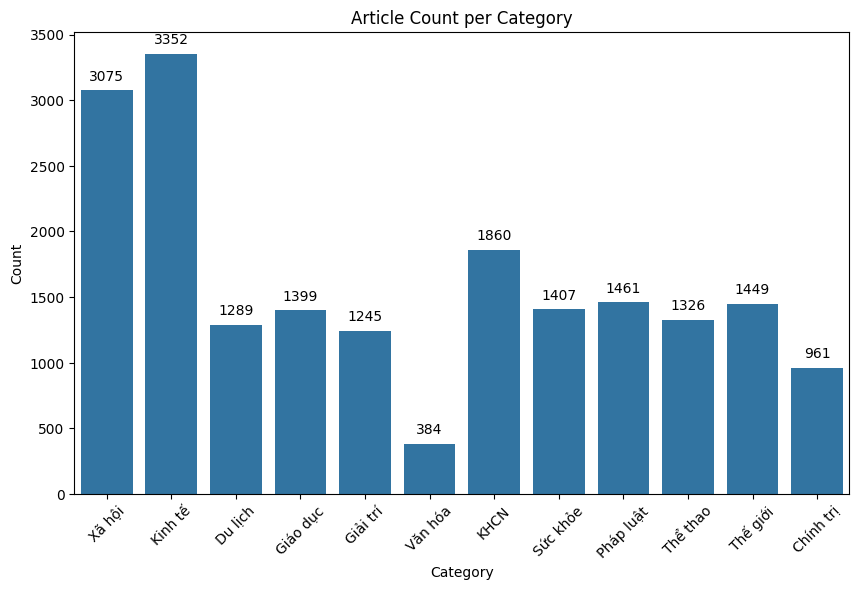

In [ ]:
# Từ điển ánh xạ các categories hiện tại về 12 loại
category_mapping = {
    "Chính trị": "Chính trị",
    "CHÍNH TRỊ": "Chính trị",
    "Thời sự": "Chính trị",
    "THỜI SỰ": "Chính trị",
    "Xã hội": "Xã hội",
    "XÃ HỘI": "Xã hội",
    "Đời sống": "Xã hội",
    "ĐỜI SỐNG": "Xã hội",
    "AN SINH": "Xã hội",
    "LAO ĐỘNG - VIỆC LÀM": "Xã hội",
    "TÌNH YÊU - GIỚI TÍNH": "Xã hội",
    "KHCN": "KHCN",
    "KHOA HỌC - CÔNG NGHỆ": "KHCN",
    "SỨC MẠNH SỐ": "KHCN",
    "Số hóa": "KHCN",
    "CÔNG NGHIỆP HỖ TRỢ": "KHCN",
    "Kinh tế": "Kinh tế",
    "KINH DOANH": "Kinh tế",
    "Kinh doanh": "Kinh tế",
    "THỊ TRƯỜNG - TIÊU DÙNG": "Kinh tế",
    "BẤT ĐỘNG SẢN": "Kinh tế",
    "Bất động sản": "Kinh tế",
    "THẾ GIỚI": "Thế giới",
    "Thế giới": "Thế giới",
    "Văn hóa": "Văn hóa",
    "VĂN HÓA": "Văn hóa",
    "GIẢI TRÍ": "Giải trí",
    "Giải trí": "Giải trí",
    "DU LỊCH": "Du lịch",
    "Du lịch": "Du lịch",
    "GIÁO DỤC": "Giáo dục",
    "Giáo dục": "Giáo dục",
    "SỨC KHỎE": "Sức khỏe",
    "Sức khỏe": "Sức khỏe",
    "Các bệnh": "Sức khỏe",
    "PHÁP LUẬT": "Pháp luật",
    "Pháp luật": "Pháp luật",
    "THỂ THAO": "Thể thao",
    "Thể thao": "Thể thao"
}
st = set()
# Lọc và chuyển đổi categories
filtered_data = []
for article in data:
    old_category = article['cat']
    if old_category in category_mapping:
        new_category = category_mapping[old_category]
        article['cat'] = new_category
        filtered_data.append(article)
    else:
        st.add(old_category)

print(st)

# In ra các bài báo sau khi lọc và chuyển đổi categories
print(f"Filtered articles count: {len(filtered_data)}")

# Trích xuất các danh mục (categories)
categories = [article['cat'] for article in filtered_data]

# Đếm số lượng từng danh mục
category_counts = {}
for category in categories:
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))  # Điều chỉnh kích thước biểu đồ nhỏ hơn
ax = sns.barplot(x=list(category_counts.keys()), y=list(category_counts.values()))
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Article Count per Category')
plt.xticks(rotation=45)

# Thêm số lượng ở trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

# Làm sạch dữ liệu hơn

In [ ]:
# Danh sách stop words tiếng Việt
stop_words = set([
    "bị", "bởi", "cả", "các", "cái", "cần", "càng", "chỉ", "chiếc", "cho", "chứ", "chưa", "chuyện",
    "có", "có_thể", "cứ", "của", "cùng", "cũng", "đã", "đang", "đây", "để", "đến_nỗi", "đều", "điều",
    "do", "đó", "được", "dưới", "gì", "khi", "không", "là", "lại", "lên", "lúc", "mà", "mỗi", "này",
    "nên", "nếu", "ngay", "nhiều", "như", "nhưng", "những", "nơi", "nữa", "phải", "qua", "ra", "rằng",
    "rằng", "rất", "rồi", "sau", "sẽ", "so", "sự", "tại", "theo", "thì", "trên", "trước", "từ", "từng",
    "và", "vẫn", "vào", "vậy", "vì", "việc", "với", "vừa"
])

# Trích xuất dữ liệu từ các bài báo đã được lọc
id = []
texts = []
labels = []

for article in filtered_data:
    id.append(article['id'])
    texts.append(article['content'])
    labels.append(article['cat'])

def preprocess(text):
    # Tokenize văn bản
    text = ViTokenizer.tokenize(text)
    # Loại bỏ ký tự đặc biệt
    text = re.sub(r'\W', ' ', text)
    # Chuyển về chữ thường
    text = text.lower()
    # Chia văn bản thành list các từ
    words = text.split()
    # Đếm số lượng từ
    original_count = len(words)
    # Loại bỏ stop words
    filtered_words = [word for word in words if word not in stop_words]
    # Đếm số lượng từ sau loại bỏ
    filtered_count = len(filtered_words)
    # Gộp các từ lại thành đoạn
    text = ' '.join(filtered_words)
    # Tính phần trăm stopword đã loại bỏ
    stopword_percentage = (original_count - filtered_count) / original_count * 100
    # Trả ra kết quả
    return text, stopword_percentage

sum_stop_words_percents = 0
processed_texts = []

tqdm_iter = tqdm(texts, desc="Processing articles")

for i, doc in enumerate(tqdm(tqdm_iter)):
    processed_content, stopword_percentage = preprocess(doc)
    processed_texts.append(processed_content)
    sum_stop_words_percents += stopword_percentage
    avg_stop_words_percent = sum_stop_words_percents / (i+1)
    tqdm_iter.set_postfix({"avg_stop_words_percent": f"{avg_stop_words_percent:.2f}%"})

texts = processed_texts
average_stopword_percentage = sum_stop_words_percents / len(texts)

print(f"Average percentage of stop words removed: {average_stopword_percentage:.2f}%")

Processing articles:   0%|          | 0/19208 [00:00<?, ?it/s]

  0%|          | 0/19208 [00:00<?, ?it/s]

Average percentage of stop words removed: 22.64%


In [ ]:
print("Văn bản sau sử lý: ", texts[0])
print("Nhãn của văn bản: ", labels[0])

Văn bản sau sử lý:  phó_thủ_tướng thăm tặng quà mẹ việt_nam anh_hùng thương_binh ở quảng_trị chiều 5 7 phó_thủ_tướng chính_phủ lê_thành long đoàn công_tác đến thăm gia_đình chính_sách địa_bàn huyện gio_linh tỉnh quảng_trị đi đoàn thứ_trưởng bộ lao_động thương_binh xã_hội lđ tb xh nguyễn_thị_hà phó_thủ_tướng lê_thành long thứ_trưởng bộ lđ tb xh nguyễn_thị_hà thăm_hỏi động_viên mẹ việt_nam anh_hùng nguyễn_thị_nậy gia_đình ảnh tiến_thành đoàn công_tác tới thăm_hỏi tặng quà mẹ việt_nam anh_hùng nguyễn_thị_nậy 95 tuổi trú xã phong_bình thương_binh lê_định 87 tuổi trú xã gio mỹ mẹ việt_nam anh_hùng nguyễn_thị_nậy chồng 1 người con liệt_sỹ hiện mẹ sống vợ_chồng người con_trai thứ thương_binh lê_định xúc_động nhận quan_tâm lãnh_đạo đảng nhà_nước ảnh tiến_thành còn ông lê_định thương_binh 1 4 ông du_kích bị_thương tháng 7 1969 ông định 5 người con vợ mất ông sống con_đẻ lê_thị_hồng bà hồng nay 60 tuổi khiếm_khuyết một phần về trí_tuệ chồng con đoàn công_tác dâng hương tri_ân nghĩa_trang liệt_sỹ

In [ ]:
cursor.close()

True

# Tạo bảng processed_texts

In [ ]:
cursor = mydb.cursor()

query = """
    CREATE TABLE processed_texts (
    doc_id INT PRIMARY KEY,
    texts TEXT,
    catcategory VARCHAR(255)
);
"""

cursor.execute(query)

## Thêm dữ liệu vào bảng

In [ ]:
for i in range(len(texts)):
    doc_id = id[i]
    text = texts[i]
    cat = labels[i]
    values = (doc_id, text, cat)
    cursor.execute(PROCESSED_TEXTS_INSERT_QUERY, values)

mydb.commit()

In [ ]:
cursor.close()

True

# Tạo vector biểu diễn cho dữ liệu

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, tokenizer=lambda x: x, preprocessor=lambda x: x, token_pattern=None)
texts_tfidf = tfidf_vectorizer.fit_transform(texts)

In [ ]:
print(texts_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 77 stored elements and shape (1, 189)>
  Coords	Values
  (0, 27)	0.029983860171851468
  (0, 19)	0.3670729023750944
  (0, 63)	0.01880047204236433
  (0, 11)	0.3196281054694699
  (0, 31)	0.26968621398986525
  (0, 142)	0.024079091165275904
  (0, 97)	0.0725440323439412
  (0, 136)	0.028632034045116193
  (0, 25)	0.47694506363022465
  (0, 18)	0.23972107910210244
  (0, 0)	0.5593491845715723
  (0, 73)	0.0181134351988259
  (0, 24)	0.06493121907123514
  (0, 118)	0.005867283419605568
  (0, 28)	0.020334571341941745
  (0, 32)	0.06742506348281199
  (0, 44)	0.057498990911135285
  (0, 119)	0.03324899197177511
  (0, 33)	0.03505773946397209
  (0, 20)	0.14233439071687332
  (0, 126)	0.0376578029453597
  (0, 12)	0.07742605298505136
  (0, 68)	0.02171802305800867
  (0, 96)	0.03820681284650593
  (0, 13)	0.042494829447956746
  :	:
  (0, 10)	0.011216921784682695
  (0, 133)	0.010732477393087518
  (0, 69)	0.0111798656556439
  (0, 9)	0.00333633578464427
 

# Lưu vocab

In [ ]:
# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

with open('vocabulary.tex', 'w', encoding='utf-8') as vocab_file:
    for i, word in enumerate(feature_names):
        vocab_file.write(f"{i}. {word}\n")

# Tạo bảng tfidf

In [ ]:
cursor = mydb.cursor()

query = """
    create table tfidf (
        doc_id INT,
        word VARCHAR(255),
        tfidf_value FLOAT,
        PRIMARY KEY (doc_id, word)
    )
"""

cursor.execute(query)

# Thêm dữ liệu vào bảng

In [ ]:
vocab_mapping = {word: f"{i}" for i, word in enumerate(feature_names)}

In [ ]:
dense_tfidf = texts_tfidf.todense()
tfidf_df = pd.DataFrame(dense_tfidf, columns=feature_names)
tfidf_df.rename(columns=vocab_mapping, inplace=True)
tfidf_df['doc_id'] = range(len(texts))
tfidf_df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,180,181,182,183,184,185,186,187,188,doc_id
0,0.559349,0.002784,0.008254,0.000000,0.000000,0.003204,0.009463,0.007001,0.010516,0.003336,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.577849,0.011652,0.001645,0.003270,0.001794,0.000000,0.007545,0.012559,0.002096,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.617719,0.043126,0.015124,0.021863,0.011996,0.011209,0.009458,0.006997,0.019270,0.013339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,0.732193,0.015257,0.015079,0.026224,0.004111,0.004390,0.004322,0.000000,0.019213,0.004571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.659271,0.016469,0.018312,0.020220,0.022190,0.009478,0.009331,0.023298,0.018147,0.007402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [ ]:
for doc_id, row in tfidf_df.iterrows():
    for word, value in row.drop('doc_id').items():
        if value > 0:
            values = (doc_id, word, value)
            cursor.execute(TFIDF_INSERT_QUERY, values)

mydb.commit()

In [ ]:
cursor.close()
mydb.close()